In [1]:
from keras.datasets.mnist import load_data
# 引入 MNIST資料集
((x_train, y_train), (x_test, y_test)) = load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [2]:
print("訓練資料維度:", x_train.shape)
print("測試資料維度:", x_test.shape)

訓練資料維度: (60000, 28, 28)
測試資料維度: (10000, 28, 28)


正確答案 3


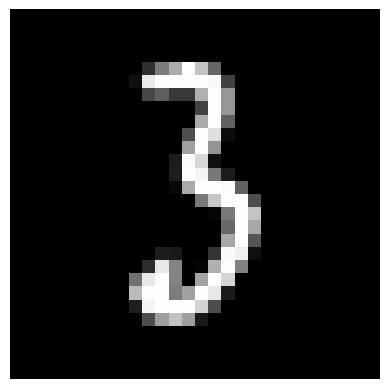

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import random
c = random.randint(0, 59999)
print("正確答案", y_train[c])
plt.axis("off")
# 取消坐標軸
plt.imshow(x_train[c], cmap="gray")

In [4]:
import pandas as pd
pd.DataFrame(x_train[c])

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,15,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
x_train_shape = x_train.reshape(60000, 784) / 255
x_test_shape = x_test.reshape(10000, 784) / 255
# 處理圖片
x_train_shape[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [6]:
from keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
# 處理答案
print("處理前:", y_train[0])
print("處理後:", y_train_cat[0])

處理前: 5
處理後: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [7]:
from keras.models import Sequential
# 引入神經網路支架
from keras.layers import Dense
# 引入神經網路內層
model = Sequential()
model.add(Dense(128, activation="relu", input_dim=784))
# 輸入神經設定activation="relu", 避免梯度下降
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))
# 一個輸出神經設定activation="sigmoid", 否則設定activation="softmax"
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 118282 (462.04 KB)
Trainable params: 118282 (462.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# 一個輸出神經設定loss="binary_crossentropy", 否則設定loss="categorical_crossentropy"

In [9]:
model.fit(x_train_shape, y_train_cat,
     batch_size=200, epochs=5, validation_split=0.1, verbose=2)
# epochs意思是模型訓練幾次

Epoch 1/5
270/270 - 5s - loss: 0.3921 - accuracy: 0.8899 - val_loss: 0.1646 - val_accuracy: 0.9555 - 5s/epoch - 17ms/step
Epoch 2/5
270/270 - 3s - loss: 0.1515 - accuracy: 0.9552 - val_loss: 0.1101 - val_accuracy: 0.9688 - 3s/epoch - 10ms/step
Epoch 3/5
270/270 - 3s - loss: 0.1032 - accuracy: 0.9696 - val_loss: 0.0881 - val_accuracy: 0.9753 - 3s/epoch - 10ms/step
Epoch 4/5
270/270 - 3s - loss: 0.0764 - accuracy: 0.9773 - val_loss: 0.0748 - val_accuracy: 0.9772 - 3s/epoch - 10ms/step
Epoch 5/5
270/270 - 3s - loss: 0.0591 - accuracy: 0.9821 - val_loss: 0.0836 - val_accuracy: 0.9752 - 3s/epoch - 9ms/step


In [10]:
model.save("MNIST.h5")
# 儲存模型

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [11]:
from keras.models import load_model
loaded = load_model("MNIST.h5")
# 載入模型

In [12]:
loaded.evaluate(x_test_shape, y_test_cat)
# 使用模型

313/313 [==============================] - 1s 2ms/step - loss: 0.0898 - accuracy: 0.9712


[0.08978479355573654, 0.9711999893188477]